# Catalog Coverage: Western, Non-Western, and International

This notebook quantifies how individuals from different polities are covered
by Western, non-Western, and international authority catalogs (library and biographical databases).
Catalogs are classified using the `country_name` field in `identifier_types`.

**Figure produced:** Stacked bar chart (%) of the top-10 polities ranked by non-Western-only share,
with Western, both, non-Western, international, and no-catalog segments.

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## 1. Setup and Western country definition

Load the database and define the set of country names considered Western.

In [2]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

DB = DB_PATH

WESTERN_COUNTRIES = {
    'United States', 'Washington, D.C.', 'Germany', 'France', 'Poland',
    'Netherlands', 'Kingdom of the Netherlands', 'United Kingdom', 'Wales',
    'Italy', 'Kingdom of Italy', 'Spain', 'Sweden', 'Norway', 'Finland',
    'Denmark', 'Faroe Islands', 'Austria', 'Belgium', 'Switzerland',
    'Portugal', 'Czech Republic', 'Slovakia', 'Greece', 'Hungary',
    'Ireland', 'Canada', 'Australia', 'New Zealand', 'Romania', 'Croatia',
    'Serbia', 'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Bulgaria',
    'Iceland', 'Luxembourg', 'Liechtenstein', 'Andorra', 'Cyprus',
    'Vatican City', 'Weimar Republic', 'German Reich',
}


## 2. Classify catalogs and pre-compute per-individual coverage

Each catalog (identifier type) is classified as Western, non-Western, international,
or unclassified based on its `country_name`.
A temporary table `ind_cat` records, for every individual, whether they appear in at
least one Western, non-Western, and/or international catalog.

In [3]:
conn = duckdb.connect(DB, read_only=True)
cur = conn.execute('SELECT property_id, country_name FROM identifier_types')
western_pids = set()
non_western_pids = set()
international_pids = set()
unclassified_pids = set()
for pid, country in cur.fetchall():
    if country and country in WESTERN_COUNTRIES:
        western_pids.add(pid)
    elif country and country == 'internationality':
        international_pids.add(pid)
    elif country:
        non_western_pids.add(pid)
    else:
        unclassified_pids.add(pid)

print(f"Catalog classification (from identifier_types.country_name):")
print(f"  Western:        {len(western_pids)}")
print(f"  Non-Western:    {len(non_western_pids)}")
print(f"  International:  {len(international_pids)}")
print(f"  Unclassified:   {len(unclassified_pids)} (no country_name)")

# Wikipedia language codes mapped to the WESTERN_COUNTRIES bloc.
WESTERN_WIKI_LANGS = {
    'en', 'simple', 'de', 'de-at', 'de-ch', 'als', 'bar', 'pdc', 'ksh',
    'fr', 'frp', 'oc', 'co', 'br', 'wa',
    'es', 'ast', 'an', 'ext', 'mwl',
    'it', 'fur', 'lij', 'lmo', 'nap', 'pms', 'rm', 'sc', 'scn', 'vec',
    'pt',
    'nl', 'fy', 'li', 'zea', 'nds-nl', 'af',
    'pl', 'csb', 'szl',
    'sv', 'no', 'nn', 'nb', 'fi', 'da', 'fo', 'is',
    'cs', 'sk', 'sr', 'hr', 'sl', 'bs',
    'el',
    'hu',
    'ga', 'cy', 'gd', 'gv', 'kw',
    'ro', 'mo', 'roa-rup',
    'lt', 'lv', 'et',
    'bg', 'mk',
    'lb',
    'ca', 'gl', 'eu',
    'la',
    'mt',
    'nds', 'eo', 'ia', 'ie', 'vo',
}

print("\nPre-computing catalog type per individual (may take a few minutes)...")

conn.execute('DROP TABLE IF EXISTS temp.w_pids')
conn.execute('CREATE TEMP TABLE w_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO w_pids VALUES (?)', [(p,) for p in western_pids])

conn.execute('DROP TABLE IF EXISTS temp.nw_pids')
conn.execute('CREATE TEMP TABLE nw_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO nw_pids VALUES (?)', [(p,) for p in non_western_pids])

conn.execute('DROP TABLE IF EXISTS temp.intl_pids')
conn.execute('CREATE TEMP TABLE intl_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO intl_pids VALUES (?)', [(p,) for p in international_pids])

conn.execute('DROP TABLE IF EXISTS temp.w_wiki_sites')
conn.execute('CREATE TEMP TABLE w_wiki_sites (site TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO w_wiki_sites VALUES (?)',
                 [(f'{lang}.wikipedia.org',) for lang in WESTERN_WIKI_LANGS])

conn.execute('DROP TABLE IF EXISTS temp.ind_cat')
conn.execute('''
    CREATE TEMP TABLE ind_cat AS
    SELECT i.wikidata_id,
           MAX(CASE WHEN wp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_western,
           MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_non_western,
           MAX(CASE WHEN ip.pid IS NOT NULL THEN 1 ELSE 0 END) as has_international
    FROM identifiers i
    LEFT JOIN w_pids wp ON i.property_id = wp.pid
    LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
    LEFT JOIN intl_pids ip ON i.property_id = ip.pid
    GROUP BY i.wikidata_id
''')
conn.execute('CREATE INDEX idx_ind_cat ON ind_cat(wikidata_id)')

print("Pre-computing Wikipedia presence (Western vs non-Western) per individual...")
conn.execute('DROP TABLE IF EXISTS temp.ind_wiki')
conn.execute('''
    CREATE TEMP TABLE ind_wiki AS
    SELECT s.wikidata_id,
           MAX(CASE WHEN ww.site IS NOT NULL THEN 1 ELSE 0 END) as has_western_wiki,
           MAX(CASE WHEN ww.site IS NULL THEN 1 ELSE 0 END) as has_non_western_wiki
    FROM wikimedia_links s
    LEFT JOIN w_wiki_sites ww ON s.site = ww.site
    WHERE s.site LIKE '%.wikipedia.org'
    GROUP BY s.wikidata_id
''')
conn.execute('CREATE INDEX idx_ind_wiki ON ind_wiki(wikidata_id)')

row = conn.execute('''
    SELECT COUNT(*), SUM(has_western), SUM(has_non_western), SUM(has_international)
    FROM ind_cat
''').fetchone()
print(f"Done! {row[0]:,} individuals with identifiers")
print(f"  Referenced by a Western catalog:        {row[1]:,} ({row[1]/row[0]*100:.1f}%)")
print(f"  Referenced by a non-Western catalog:     {row[2]:,} ({row[2]/row[0]*100:.1f}%)")
print(f"  Referenced by an international catalog:  {row[3]:,} ({row[3]/row[0]*100:.1f}%)")

w_row = conn.execute(
    'SELECT COUNT(*), SUM(has_western_wiki), SUM(has_non_western_wiki) FROM ind_wiki'
).fetchone()
print(f"  With at least one Wikipedia sitelink:    {w_row[0]:,}")
print(f"    Western Wikipedia(s):                  {w_row[1]:,}")
print(f"    Non-Western Wikipedia(s):              {w_row[2]:,}")

TypeError: '_duckdb.DuckDBPyConnection' object is not iterable

In [ ]:
import pandas as pd

df_ind_cat = conn.execute("SELECT * FROM ind_cat LIMIT 20").df()
print("Per-individual catalog coverage (first 20 rows):")
df_ind_cat

## 3. Top 10 polities by non-Western-only catalog share

Polities with at least 2,000 individuals, ranked by the share of individuals
appearing only in non-Western catalogs. International catalogs are shown
as a separate category.

In [ ]:
cur = conn.execute('''
    SELECT c.polity_name,
           COUNT(*) AS total,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=0 THEN 1 ELSE 0 END) AS w_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END) AS both_cat,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END) AS nw_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=1 THEN 1 ELSE 0 END) AS intl_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=0
                     AND COALESCE(iw.has_western_wiki,0)=1
                     AND COALESCE(iw.has_non_western_wiki,0)=0 THEN 1 ELSE 0 END) AS wiki_w_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=0
                     AND COALESCE(iw.has_western_wiki,0)=1
                     AND COALESCE(iw.has_non_western_wiki,0)=1 THEN 1 ELSE 0 END) AS wiki_both,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=0
                     AND COALESCE(iw.has_western_wiki,0)=0
                     AND COALESCE(iw.has_non_western_wiki,0)=1 THEN 1 ELSE 0 END) AS wiki_nw_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=0
                     AND iw.wikidata_id IS NULL THEN 1 ELSE 0 END) AS no_catalog
    FROM consolidated_database c
    LEFT JOIN ind_cat ic ON c.wikidata_id = ic.wikidata_id
    LEFT JOIN ind_wiki iw ON c.wikidata_id = iw.wikidata_id
    WHERE c.polity_name IS NOT NULL
    GROUP BY c.polity_name
    HAVING total >= 2000
''')

raw_rows = cur.fetchall()

def clean_polity_name(compound):
    for part in compound.split(';'):
        part = part.strip()
        if not part.startswith('('):
            return part
    return compound.split(';')[0].strip('() ')

seen = {}
for (polity_name, total, w_only, both_cat, nw_only, intl_only,
     wiki_w, wiki_both, wiki_nw, no_catalog) in raw_rows:
    display_name = clean_polity_name(polity_name)
    if display_name not in seen or nw_only > seen[display_name][4]:
        seen[display_name] = (polity_name, total, w_only, both_cat, nw_only,
                              intl_only, wiki_w, wiki_both, wiki_nw, no_catalog)

polity_rows = sorted(seen.values(), key=lambda r: r[4] / r[1], reverse=True)[:10]

print(f"{'Polity':<40} {'Total':>8} {'W only':>8} {'Both':>8} {'NW only':>8} {'Intl':>8} {'WikiW':>8} {'WikiB':>8} {'WikiNW':>8} {'None':>8} {'NW %':>6}")
print('-' * 132)
for (polity_name, total, w_only, both_cat, nw_only, intl_only,
     wiki_w, wiki_both, wiki_nw, no_catalog) in polity_rows:
    display_name = clean_polity_name(polity_name)
    print(f"{display_name:<40} {total:>8,} {w_only:>8,} {both_cat:>8,} {nw_only:>8,} {intl_only:>8,} "
          f"{wiki_w:>8,} {wiki_both:>8,} {wiki_nw:>8,} {no_catalog:>8,} {nw_only/total*100:>5.1f}%")

Polity                                      Total   W only     Both  NW only     Intl    WikiW    WikiB   WikiNW     None   NW %
------------------------------------------------------------------------------------------------------------------------------------
Oriental Republic of Uruguay               16,418      984    2,928    9,202      130    1,446      947       23      758  56.0%
Republic of Peru                           18,874    4,564    1,930    5,571      687    3,651      812       29    1,630  29.5%
Russian Federation                         68,539   11,632    8,864   17,405    1,010    1,976    6,589   15,243    5,820  25.4%
Republic of Indonesia                      93,326    4,832    1,006   19,868      660      549    1,930    8,611   55,870  21.3%
Iraqi Republic                              3,047      458      340      578      135       77      602      673      184  19.0%
Empire of Japan                            35,603    1,424   10,356    6,273        0      31

In [ ]:
df_top10 = pd.DataFrame(
    [(clean_polity_name(r[0]), r[1], r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9]) for r in polity_rows],
    columns=['polity', 'total', 'western_only', 'both', 'non_western_only',
             'international_only', 'wikipedia_western_only', 'wikipedia_both',
             'wikipedia_non_western_only', 'no_catalog']
)
df_top10['nw_pct'] = (df_top10['non_western_only'] / df_top10['total'] * 100).round(1)
print("Top 10 polities by non-Western-only catalog share:")
df_top10

Top 10 polities by non-Western-only catalog share:


,polity,total,western_only,both,non_western_only,international_only,wikipedia_western_only,wikipedia_both,wikipedia_non_western_only,no_catalog,nw_pct
0,Oriental Republic of Uruguay,16418,984,2928,9202,130,1446,947,23,758,56.0
1,Republic of Peru,18874,4564,1930,5571,687,3651,812,29,1630,29.5
2,Russian Federation,68539,11632,8864,17405,1010,1976,6589,15243,5820,25.4
3,Republic of Indonesia,93326,4832,1006,19868,660,549,1930,8611,55870,21.3
4,Iraqi Republic,3047,458,340,578,135,77,602,673,184,19.0
5,Empire of Japan,35603,1424,10356,6273,0,310,1306,14564,1370,17.6
6,Hungarian Republic,2096,702,35,350,14,233,9,13,740,16.7
7,Federated Republic of Brazil,12284,2541,1299,1992,967,3136,774,26,1549,16.2
8,Tanzania,3425,270,81,552,236,155,378,262,1491,16.1
9,Japan,182190,22567,58019,28334,1027,1686,6264,58305,5988,15.6


In [ ]:
df_top10['percent_non_western']=df_top10['non_western_only']/df_top10['total']
df_top10.sort_values('percent_non_western', ascending=False)

,polity,total,western_only,both,non_western_only,international_only,wikipedia_western_only,wikipedia_both,wikipedia_non_western_only,no_catalog,nw_pct,percent_non_western
0,Oriental Republic of Uruguay,16418,984,2928,9202,130,1446,947,23,758,56.0,0.560482
1,Republic of Peru,18874,4564,1930,5571,687,3651,812,29,1630,29.5,0.295168
2,Russian Federation,68539,11632,8864,17405,1010,1976,6589,15243,5820,25.4,0.253943
3,Republic of Indonesia,93326,4832,1006,19868,660,549,1930,8611,55870,21.3,0.212888
4,Iraqi Republic,3047,458,340,578,135,77,602,673,184,19.0,0.189695
5,Empire of Japan,35603,1424,10356,6273,0,310,1306,14564,1370,17.6,0.176193
6,Hungarian Republic,2096,702,35,350,14,233,9,13,740,16.7,0.166985
7,Federated Republic of Brazil,12284,2541,1299,1992,967,3136,774,26,1549,16.2,0.162162
8,Tanzania,3425,270,81,552,236,155,378,262,1491,16.1,0.161168
9,Japan,182190,22567,58019,28334,1027,1686,6264,58305,5988,15.6,0.155519


### Figure: Top-10 polities by non-Western-only share (%)

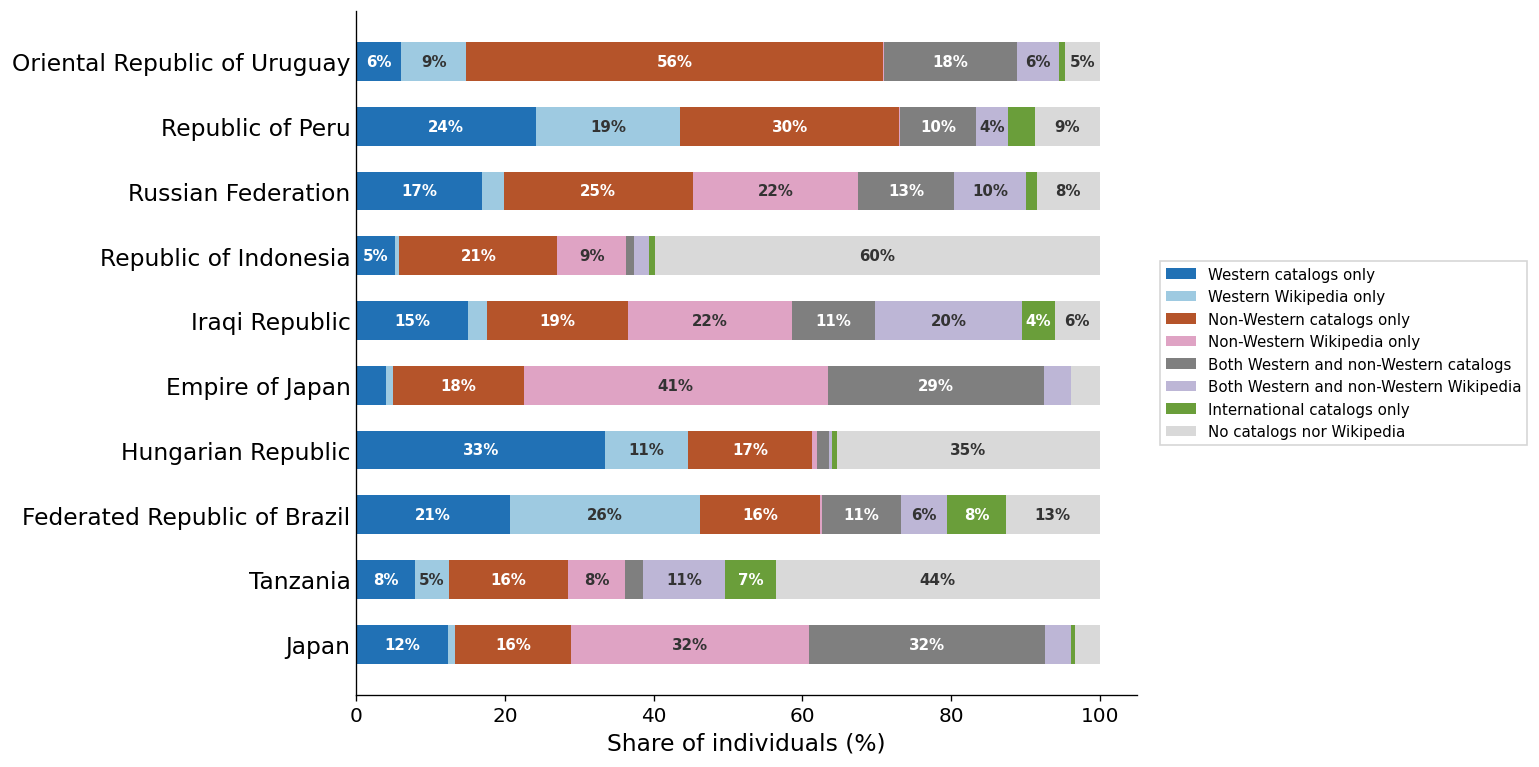

In [ ]:
labels_p     = [clean_polity_name(r[0]) for r in polity_rows]
totals       = np.array([r[1] for r in polity_rows], dtype=float)
w_only_p     = np.array([r[2] for r in polity_rows]) / totals * 100
both_cat_p   = np.array([r[3] for r in polity_rows]) / totals * 100
nw_only_p    = np.array([r[4] for r in polity_rows]) / totals * 100
intl_only_p  = np.array([r[5] for r in polity_rows]) / totals * 100
wiki_w_p     = np.array([r[6] for r in polity_rows]) / totals * 100
wiki_both_p  = np.array([r[7] for r in polity_rows]) / totals * 100
wiki_nw_p    = np.array([r[8] for r in polity_rows]) / totals * 100
no_cat_p     = np.array([r[9] for r in polity_rows]) / totals * 100

labels_p     = labels_p[::-1]
w_only_p     = w_only_p[::-1]
both_cat_p   = both_cat_p[::-1]
nw_only_p    = nw_only_p[::-1]
intl_only_p  = intl_only_p[::-1]
wiki_w_p     = wiki_w_p[::-1]
wiki_both_p  = wiki_both_p[::-1]
wiki_nw_p    = wiki_nw_p[::-1]
no_cat_p     = no_cat_p[::-1]

# Order from left to right:
# 1. Western catalogs only
# 2. Western Wikipedia only
# 3. Non-Western catalogs only
# 4. Non-Western Wikipedia only
# 5. Both catalogs (Western + non-Western)
# 6. Both Wikipedia (Western + non-Western)
# 7. International catalogs only
# 8. No catalogs nor Wikipedia
segments = [
    ('Western catalogs only',                w_only_p,    '#2171b5'),
    ('Western Wikipedia only',               wiki_w_p,    '#9ecae1'),
    ('Non-Western catalogs only',            nw_only_p,   '#b5542a'),
    ('Non-Western Wikipedia only',           wiki_nw_p,   '#dfa3c4'),
    ('Both Western and non-Western catalogs',  both_cat_p,  '#7f7f7f'),
    ('Both Western and non-Western Wikipedia', wiki_both_p, '#bdb6d6'),
    ('International catalogs only',          intl_only_p, '#6a9e3a'),
    ('No catalogs nor Wikipedia',            no_cat_p,    '#d9d9d9'),
]

y = np.arange(len(labels_p))
height = 0.6
LABEL_THRESHOLD = 4.0  # show '%' label inside segment when share >= 4%

fig, ax = plt.subplots(figsize=(13, 6.5))

left = np.zeros(len(labels_p))
for label, vals, color in segments:
    bars = ax.barh(y, vals, height=height, left=left, color=color, label=label)
    for i, (bar, v, l_i) in enumerate(zip(bars, vals, left)):
        if v >= LABEL_THRESHOLD:
            ax.text(l_i + v / 2, y[i], f'{v:.0f}%',
                    ha='center', va='center', fontsize=9,
                    color='white' if color not in ('#9ecae1', '#dfa3c4', '#bdb6d6', '#d9d9d9') else '#333',
                    fontweight='bold')
    left = left + vals

ax.set_yticks(y)
ax.set_yticklabels(labels_p, fontsize=14)
ax.set_xlabel('Share of individuals (%)', fontsize=14)
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', length=0)
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=True, fancybox=False, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

### Figure: Distribution of catalog/Wikipedia coverage before vs after 1900

Two pie charts showing the share of individuals in each of the eight coverage
categories, split by impact year (< 1900 vs ≥ 1900). Same colour scheme as the
top-10 polities chart.

Before 1900: 1,704,392 individuals
After 1900:  5,803,969 individuals


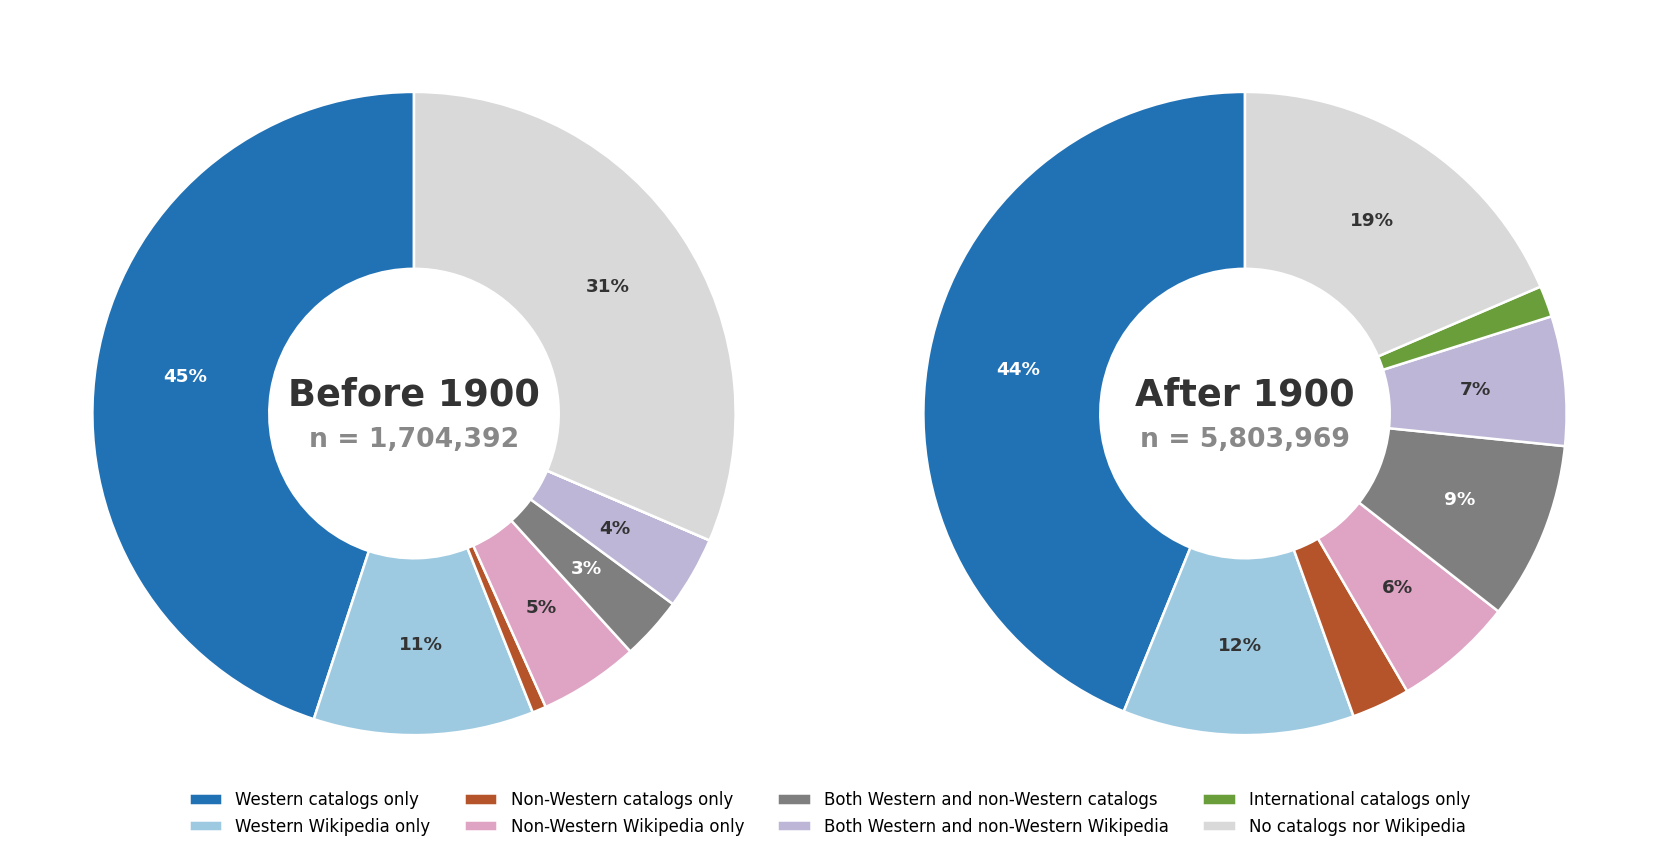

In [ ]:
cur = conn.execute('''
    SELECT
        CASE WHEN id.floruit_period_start < 1900 THEN 'before_1900' ELSE 'after_1900' END AS period,
        COUNT(*) AS total,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=0 THEN 1 ELSE 0 END) AS w_only,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END) AS both_cat,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END) AS nw_only,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                  AND COALESCE(ic.has_international,0)=1 THEN 1 ELSE 0 END) AS intl_only,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                  AND COALESCE(ic.has_international,0)=0
                  AND COALESCE(iw.has_western_wiki,0)=1
                  AND COALESCE(iw.has_non_western_wiki,0)=0 THEN 1 ELSE 0 END) AS wiki_w,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                  AND COALESCE(ic.has_international,0)=0
                  AND COALESCE(iw.has_western_wiki,0)=1
                  AND COALESCE(iw.has_non_western_wiki,0)=1 THEN 1 ELSE 0 END) AS wiki_both,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                  AND COALESCE(ic.has_international,0)=0
                  AND COALESCE(iw.has_western_wiki,0)=0
                  AND COALESCE(iw.has_non_western_wiki,0)=1 THEN 1 ELSE 0 END) AS wiki_nw,
        SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                  AND COALESCE(ic.has_international,0)=0
                  AND iw.wikidata_id IS NULL THEN 1 ELSE 0 END) AS no_catalog
    FROM individuals_floruit_period id
    LEFT JOIN ind_cat ic ON id.wikidata_id = ic.wikidata_id
    LEFT JOIN ind_wiki iw ON id.wikidata_id = iw.wikidata_id
    WHERE id.floruit_period_start IS NOT NULL
    GROUP BY period
''')
period_rows = {r[0]: r for r in cur.fetchall()}

PIE_SEGMENTS = [
    ('Western catalogs only',                  '#2171b5'),
    ('Western Wikipedia only',                 '#9ecae1'),
    ('Non-Western catalogs only',              '#b5542a'),
    ('Non-Western Wikipedia only',             '#dfa3c4'),
    ('Both Western and non-Western catalogs',  '#7f7f7f'),
    ('Both Western and non-Western Wikipedia', '#bdb6d6'),
    ('International catalogs only',            '#6a9e3a'),
    ('No catalogs nor Wikipedia',              '#d9d9d9'),
]

def values_for(row):
    # row order: period, total, w_only, both_cat, nw_only, intl_only,
    #            wiki_w, wiki_both, wiki_nw, no_catalog
    _, total, w_only, both_cat, nw_only, intl_only, wiki_w, wiki_both, wiki_nw, no_catalog = row
    return total, [w_only, wiki_w, nw_only, wiki_nw, both_cat, wiki_both, intl_only, no_catalog]

total_before, vals_before = values_for(period_rows['before_1900'])
total_after,  vals_after  = values_for(period_rows['after_1900'])

print(f"Before 1900: {total_before:,} individuals")
print(f"After 1900:  {total_after:,} individuals")

colors_pie = [c for _, c in PIE_SEGMENTS]
labels_pie = [l for l, _ in PIE_SEGMENTS]
LIGHT_COLORS = {'#9ecae1', '#dfa3c4', '#bdb6d6', '#d9d9d9'}

def autopct(pct):
    return f'{pct:.0f}%' if pct >= 3 else ''

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (vals, total, period_label) in zip(
    axes,
    [(vals_before, total_before, 'Before 1900'),
     (vals_after,  total_after,  'After 1900')],
):
    wedges, texts, autotexts = ax.pie(
        vals, colors=colors_pie, autopct=autopct, pctdistance=0.72,
        startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    )
    for autotext, color in zip(autotexts, colors_pie):
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('#333' if color in LIGHT_COLORS else 'white')
    ax.text(0, 0.06, period_label,
            ha='center', va='center', fontsize=22, color='#333', fontweight='bold')
    ax.text(0, -0.08, f'n = {total:,}',
            ha='center', va='center', fontsize=16, color='#888', fontweight='bold')

fig.legend(wedges, labels_pie, loc='lower center', ncol=4, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

## Cleanup

In [ ]:
conn.close()